Usando dispositivo: cuda:0
GPU detectada: Tesla T4


100%|██████████| 170M/170M [24:17<00:00, 117kB/s]  


Train: 50000 imágenes | Test: 10000 imágenes
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d

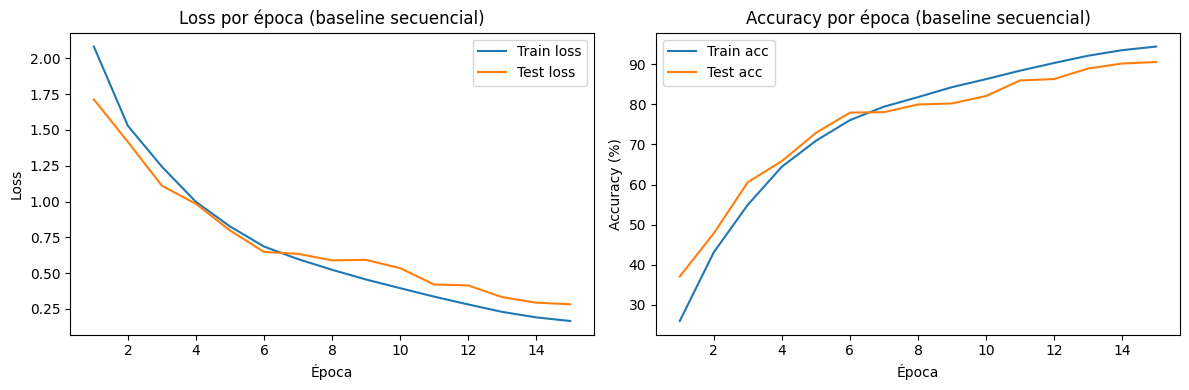


Resumen: 15 épocas, 667.2s totales, 44.5s/época en promedio, test_acc final = 90.54%


In [2]:
# =============================================================================
# BASELINE SECUENCIAL: CIFAR-10 + ResNet18
# =============================================================================
# Cómo usarlo en Kaggle:
#   1. Crea un nuevo Notebook en Kaggle (kaggle.com/code -> New Notebook).
#   2. En el panel derecho, Settings -> Accelerator -> elige "GPU T4 x2"
#      (aunque este script solo use 1 GPU, actívalo así porque el siguiente
#      script, el de entrenamiento distribuido, sí necesita las 2).
#   3. Settings -> Internet -> ON (para descargar CIFAR-10 automáticamente).
#   4. Copia cada bloque separado por "# --- CELDA N ---" en una celda
#      distinta del notebook, en orden, y ejecuta.
#
# Qué hace:
#   - Descarga CIFAR-10 (torchvision se encarga).
#   - Adapta ResNet18 (diseñado para ImageNet 224x224) a imágenes de 32x32:
#     cambia el primer conv a 3x3/stride 1 y quita el maxpool inicial.
#     Sin este cambio, ResNet18 reduce demasiado la imagen y el accuracy
#     se queda muy bajo en CIFAR-10.
#   - Entrena de forma 100% secuencial (1 GPU, sin paralelismo).
#   - Guarda tiempos por época y métricas en baseline_metrics.json:
#     esto es lo que vas a comparar después contra la versión distribuida.
# =============================================================================

# --- CELDA 1: imports y configuración ---
import time
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

SEED = 42
NUM_EPOCHS = 15          # súbelo a 30-40 si te alcanza el tiempo de Kaggle
BATCH_SIZE = 128
LR = 0.1
NUM_WORKERS = 2
OUTPUT_METRICS_FILE = "baseline_metrics.json"
OUTPUT_MODEL_FILE = "baseline_resnet18_cifar10.pth"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

# --- CELDA 2: datos (CIFAR-10) ---
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
test_loader = DataLoader(
    test_set, batch_size=256, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_set)} imágenes | Test: {len(test_set)} imágenes")

# --- CELDA 3: modelo (ResNet18 adaptado a CIFAR-10) ---
def build_resnet18_cifar(num_classes=10):
    model = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    # ResNet18 estándar está pensado para imágenes de 224x224 (ImageNet).
    # Para 32x32 hay que evitar reducir la resolución demasiado rápido:
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

model = build_resnet18_cifar(num_classes=10).to(device)
print(model)

# --- CELDA 4: loss, optimizer, scheduler ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- CELDA 5: funciones de entrenamiento y evaluación ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total

# --- CELDA 6: loop principal de entrenamiento ---
history = {
    "epoch": [], "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [], "epoch_time_sec": [],
}

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    epoch_time = time.time() - epoch_start

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["epoch_time_sec"].append(epoch_time)

    print(f"[Época {epoch:02d}/{NUM_EPOCHS}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
          f"test_loss={test_loss:.4f} test_acc={test_acc:.2f}% | "
          f"tiempo={epoch_time:.1f}s")

total_time = time.time() - total_start
print(f"\nEntrenamiento secuencial terminado en {total_time:.1f}s "
      f"({total_time/60:.2f} min) para {NUM_EPOCHS} épocas.")

# --- CELDA 7: guardar métricas y modelo (para comparar luego con la versión distribuida) ---
metrics = {
    "mode": "sequential_baseline",
    "num_gpus": 1,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "total_time_sec": total_time,
    "avg_epoch_time_sec": sum(history["epoch_time_sec"]) / len(history["epoch_time_sec"]),
    "final_train_acc": history["train_acc"][-1],
    "final_test_acc": history["test_acc"][-1],
    "history": history,
}

with open(OUTPUT_METRICS_FILE, "w") as f:
    json.dump(metrics, f, indent=2)

torch.save(model.state_dict(), OUTPUT_MODEL_FILE)
print(f"Métricas guardadas en {OUTPUT_METRICS_FILE}")
print(f"Modelo guardado en {OUTPUT_MODEL_FILE}")

# --- CELDA 8: graficar curvas ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Train loss")
axes[0].plot(history["epoch"], history["test_loss"], label="Test loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss por época (baseline secuencial)")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_acc"], label="Train acc")
axes[1].plot(history["epoch"], history["test_acc"], label="Test acc")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy por época (baseline secuencial)")
axes[1].legend()

plt.tight_layout()
plt.savefig("baseline_curves.png", dpi=150)
plt.show()

print(f"\nResumen: {NUM_EPOCHS} épocas, {total_time:.1f}s totales, "
      f"{metrics['avg_epoch_time_sec']:.1f}s/época en promedio, "
      f"test_acc final = {metrics['final_test_acc']:.2f}%")

In [14]:
%%writefile train_ddp.py

# =============================================================================
# ENTRENAMIENTO DISTRIBUIDO DDP: CIFAR-10 + ResNet18
# =============================================================================
#
# Ejecutar en Kaggle:
#
#   !torchrun --standalone --nproc_per_node=2 train_ddp.py
#
# Configuración Kaggle:
#   Settings -> Accelerator -> GPU T4 x2
#   Settings -> Internet -> ON
#
# Comparación contra baseline:
#
#   Baseline:
#       1 GPU
#       batch global = 128
#
#   DDP:
#       2 GPUs
#       batch global = 128
#       GPU 0 -> batch 64
#       GPU 1 -> batch 64
#
# =============================================================================


# =============================================================================
# IMPORTANTE: CONFIGURACIÓN NCCL
# =============================================================================
#
# Estas variables DEBEN definirse antes de inicializar
# torch.distributed.
#
# Kaggle puede presentar problemas de comunicación P2P entre las T4.
#
# =============================================================================

import os

os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_IB_DISABLE"] = "1"


# =============================================================================
# IMPORTS
# =============================================================================

import json
import random
import time

import numpy as np

import torch
import torch.distributed as dist
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.nn.parallel import DistributedDataParallel as DDP

from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler


# =============================================================================
# CONFIGURACIÓN
# =============================================================================

SEED = 42

NUM_EPOCHS = 15

# ============================================================================
# IMPORTANTE
#
# Este es el BATCH GLOBAL.
#
# Con 2 GPUs:
#
#   128 / 2 = 64
#
# GPU 0 -> 64
# GPU 1 -> 64
#
# Esto permite comparar contra el baseline:
#
#   Baseline -> batch 128
#   DDP      -> batch global 128
# ============================================================================

GLOBAL_BATCH_SIZE = 128

LR = 0.1

NUM_WORKERS = 2

RESULTS_DIR = "results_ddp"

MEAN = (0.4914, 0.4822, 0.4465)

STD = (0.2470, 0.2435, 0.2616)


# =============================================================================
# SEMILLA
# =============================================================================

def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


# =============================================================================
# MODELO
# =============================================================================

def build_resnet18_cifar(num_classes=10):

    model = torchvision.models.resnet18(
        weights=None,
        num_classes=num_classes
    )

    # =========================================================================
    # ResNet18 original está diseñada para ImageNet (224x224).
    #
    # CIFAR-10 utiliza imágenes 32x32.
    #
    # Por eso:
    #
    #   Conv original:
    #       7x7, stride 2
    #
    #   Conv adaptada:
    #       3x3, stride 1
    #
    # Además eliminamos el MaxPool inicial.
    # =========================================================================

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    return model


# =============================================================================
# ACCURACY
# =============================================================================

def accuracy_from_logits(outputs, targets):

    _, predicted = outputs.max(1)

    total = targets.size(0)

    correct = predicted.eq(targets).sum().item()

    return correct, total


# =============================================================================
# ENTRENAMIENTO DE UNA ÉPOCA
# =============================================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    # =========================================================================
    # CADA GPU PROCESA SU PROPIO SHARD DEL DATASET
    # =========================================================================

    for inputs, targets in loader:

        inputs = inputs.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        # ---------------------------------------------------------------------
        # Forward
        # ---------------------------------------------------------------------

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs,
            targets
        )


        # ---------------------------------------------------------------------
        # Backward
        # ---------------------------------------------------------------------

        loss.backward()

        # =========================================================================
        # IMPORTANTE:
        #
        # DDP sincroniza automáticamente los gradientes entre las GPUs
        # durante el backward().
        #
        # Conceptualmente:
        #
        #       GPU 0              GPU 1
        #         │                  │
        #       grad 0             grad 1
        #         │                  │
        #         └──── ALL-REDUCE ─┘
        #                  │
        #             grad promedio
        #                  │
        #              optimizer
        #
        # =========================================================================


        optimizer.step()


        # ---------------------------------------------------------------------
        # Métricas locales
        # ---------------------------------------------------------------------

        running_loss += (
            loss.item() * inputs.size(0)
        )

        c, t = accuracy_from_logits(
            outputs,
            targets
        )

        correct += c

        total += t


    # =========================================================================
    # COMBINAR MÉTRICAS DE LAS DOS GPUs
    # =========================================================================

    stats = torch.tensor(
        [
            running_loss,
            correct,
            total
        ],
        dtype=torch.float64,
        device=device
    )

    dist.all_reduce(
        stats,
        op=dist.ReduceOp.SUM
    )

    running_loss = stats[0].item()

    correct = stats[1].item()

    total = stats[2].item()


    return (
        running_loss / total,
        100.0 * correct / total
    )


# =============================================================================
# EVALUACIÓN
# =============================================================================
#
# IMPORTANTE:
#
# TODOS LOS RANKS ejecutan esta función.
#
# Esto corrige el error del código anterior.
#
# Si evaluate() utiliza all_reduce(), todos los procesos deben participar.
#
# =============================================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0


    for inputs, targets in loader:

        inputs = inputs.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )


        outputs = model(inputs)

        loss = criterion(
            outputs,
            targets
        )


        running_loss += (
            loss.item() * inputs.size(0)
        )

        c, t = accuracy_from_logits(
            outputs,
            targets
        )

        correct += c

        total += t


    # =========================================================================
    # TODOS LOS PROCESOS LLEGAN AQUÍ
    #
    # Por lo tanto el all_reduce NO se queda esperando.
    # =========================================================================

    stats = torch.tensor(
        [
            running_loss,
            correct,
            total
        ],
        dtype=torch.float64,
        device=device
    )

    dist.all_reduce(
        stats,
        op=dist.ReduceOp.SUM
    )

    running_loss = stats[0].item()

    correct = stats[1].item()

    total = stats[2].item()


    return (
        running_loss / total,
        100.0 * correct / total
    )


# =============================================================================
# MAIN
# =============================================================================

def main():


    # =========================================================================
    # 1. INICIALIZAR PROCESO DISTRIBUIDO
    # =========================================================================

    dist.init_process_group(
        backend="nccl"
    )


    # =========================================================================
    # 2. IDENTIFICAR RANK Y GPU
    # =========================================================================

    local_rank = int(
        os.environ["LOCAL_RANK"]
    )

    rank = dist.get_rank()

    world_size = dist.get_world_size()


    # =========================================================================
    # 3. ASIGNAR GPU
    # =========================================================================

    torch.cuda.set_device(
        local_rank
    )

    device = torch.device(
        f"cuda:{local_rank}"
    )


    # =========================================================================
    # 4. SEMILLA
    # =========================================================================

    set_seed()


    # =========================================================================
    # 5. INFORMACIÓN DEL EXPERIMENTO
    # =========================================================================

    if rank == 0:

        os.makedirs(
            RESULTS_DIR,
            exist_ok=True
        )

        print()
        print("========================================")
        print("ENTRENAMIENTO DISTRIBUIDO DDP")
        print("========================================")

        print(
            f"Mundo distribuido: world_size={world_size}"
        )

        print(
            f"GPUs utilizadas: {world_size}"
        )

        print(
            f"NCCL_P2P_DISABLE = "
            f"{os.environ['NCCL_P2P_DISABLE']}"
        )

        print(
            f"NCCL_IB_DISABLE = "
            f"{os.environ['NCCL_IB_DISABLE']}"
        )


    # =========================================================================
    # 6. BATCH POR GPU
    # =========================================================================

    assert GLOBAL_BATCH_SIZE % world_size == 0

    per_gpu_batch_size = (
        GLOBAL_BATCH_SIZE // world_size
    )


    if rank == 0:

        print(
            f"Batch global: "
            f"{GLOBAL_BATCH_SIZE}"
        )

        print(
            f"Batch por GPU: "
            f"{per_gpu_batch_size}"
        )

        print()


    # =========================================================================
    # 7. TRANSFORMACIONES
    # =========================================================================

    transform_train = transforms.Compose([

        transforms.RandomCrop(
            32,
            padding=4
        ),

        transforms.RandomHorizontalFlip(),

        transforms.ToTensor(),

        transforms.Normalize(
            MEAN,
            STD
        )

    ])


    transform_test = transforms.Compose([

        transforms.ToTensor(),

        transforms.Normalize(
            MEAN,
            STD
        )

    ])


    # =========================================================================
    # 8. DATASET
    # =========================================================================

    train_set = torchvision.datasets.CIFAR10(

        root="./data",

        train=True,

        download=True,

        transform=transform_train

    )


    test_set = torchvision.datasets.CIFAR10(

        root="./data",

        train=False,

        download=True,

        transform=transform_test

    )


    if rank == 0:

        print(
            f"Train: {len(train_set)} imágenes"
        )

        print(
            f"Test: {len(test_set)} imágenes"
        )

        print()


    # =========================================================================
    # 9. DISTRIBUTED SAMPLER
    # =========================================================================
    #
    # El sampler divide el dataset entre los procesos.
    #
    # Con 2 GPUs:
    #
    #       Dataset
    #          │
    #     ┌────┴────┐
    #     ↓         ↓
    #   GPU 0     GPU 1
    #   shard 0   shard 1
    #
    # =========================================================================

    train_sampler = DistributedSampler(

        train_set,

        num_replicas=world_size,

        rank=rank,

        shuffle=True,

        seed=SEED

    )


    # =========================================================================
    # 10. TRAIN DATALOADER
    # =========================================================================

    train_loader = DataLoader(

        train_set,

        batch_size=per_gpu_batch_size,

        sampler=train_sampler,

        num_workers=NUM_WORKERS,

        pin_memory=True,

        drop_last=True

    )


    # =========================================================================
    # 11. TEST DATALOADER
    # =========================================================================
    #
    # Ambos procesos evalúan.
    #
    # Esto es necesario porque evaluate() utiliza all_reduce().
    #
    # =========================================================================

    test_loader = DataLoader(

        test_set,

        batch_size=256,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=True

    )


    # =========================================================================
    # 12. MODELO
    # =========================================================================

    model = build_resnet18_cifar(
        num_classes=10
    ).to(device)


    # =========================================================================
    # 13. CONVERTIR MODELO A DDP
    # =========================================================================

    model = DDP(

        model,

        device_ids=[local_rank]

    )


    # =========================================================================
    # 14. LOSS
    # =========================================================================

    criterion = nn.CrossEntropyLoss()


    # =========================================================================
    # 15. OPTIMIZER
    # =========================================================================

    optimizer = optim.SGD(

        model.parameters(),

        lr=LR,

        momentum=0.9,

        weight_decay=5e-4

    )


    # =========================================================================
    # 16. LEARNING RATE SCHEDULER
    # =========================================================================

    scheduler = optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=NUM_EPOCHS

    )


    # =========================================================================
    # 17. HISTORIAL
    # =========================================================================

    history = {

        "epoch": [],

        "train_loss": [],

        "train_acc": [],

        "test_loss": [],

        "test_acc": [],

        "epoch_time_sec": []

    }


    # =========================================================================
    # 18. SINCRONIZAR ANTES DE COMENZAR
    # =========================================================================

    dist.barrier()


    total_start = time.time()


    # =========================================================================
    # 19. LOOP DE ENTRENAMIENTO
    # =========================================================================

    for epoch in range(
        1,
        NUM_EPOCHS + 1
    ):


        # =====================================================================
        # Cambiar el orden del dataset.
        #
        # Todos los procesos utilizan el mismo epoch.
        # =====================================================================

        train_sampler.set_epoch(
            epoch
        )


        # =====================================================================
        # Sincronización antes de medir
        # =====================================================================

        dist.barrier()


        epoch_start = time.time()


        # =====================================================================
        # ENTRENAMIENTO
        # =====================================================================

        train_loss, train_acc = train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer,

            device

        )


        # =====================================================================
        # Esperar a que AMBAS GPUs terminen
        # =====================================================================

        dist.barrier()


        epoch_time = (
            time.time() - epoch_start
        )


        # =====================================================================
        # Actualizar learning rate
        # =====================================================================

        scheduler.step()


        # =====================================================================
        # EVALUACIÓN
        #
        # IMPORTANTE:
        #
        # TODOS los ranks ejecutan evaluate().
        #
        # Pero SOLO rank 0 guarda/imprime.
        # =====================================================================

        test_loss, test_acc = evaluate(

            model,

            test_loader,

            criterion,

            device

        )


        # =====================================================================
        # SOLO GPU 0 GUARDA RESULTADOS
        # =====================================================================

        if rank == 0:

            history["epoch"].append(
                epoch
            )

            history["train_loss"].append(
                train_loss
            )

            history["train_acc"].append(
                train_acc
            )

            history["test_loss"].append(
                test_loss
            )

            history["test_acc"].append(
                test_acc
            )

            history["epoch_time_sec"].append(
                epoch_time
            )


            print(

                f"[Época {epoch:02d}/{NUM_EPOCHS}] "

                f"train_loss={train_loss:.4f} "

                f"train_acc={train_acc:.2f}% | "

                f"test_loss={test_loss:.4f} "

                f"test_acc={test_acc:.2f}% | "

                f"tiempo={epoch_time:.1f}s"

            )


    # =========================================================================
    # 20. TIEMPO TOTAL
    # =========================================================================

    dist.barrier()


    total_time = (
        time.time() - total_start
    )


    # =========================================================================
    # 21. GUARDAR RESULTADOS
    # =========================================================================

    if rank == 0:


        print()

        print(
            "========================================"
        )

        print(
            "ENTRENAMIENTO DDP TERMINADO"
        )

        print(
            "========================================"
        )

        print(
            f"Tiempo total: "
            f"{total_time:.1f}s"
        )

        print(
            f"Tiempo total: "
            f"{total_time / 60:.2f} minutos"
        )

        print(
            f"GPUs utilizadas: "
            f"{world_size}"
        )


        # =====================================================================
        # MÉTRICAS
        # =====================================================================

        metrics = {

            "mode": "ddp",

            "num_gpus": world_size,

            "num_epochs": NUM_EPOCHS,

            "global_batch_size":
                GLOBAL_BATCH_SIZE,

            "per_gpu_batch_size":
                per_gpu_batch_size,

            "total_time_sec":
                total_time,

            "avg_epoch_time_sec":
                sum(
                    history["epoch_time_sec"]
                )
                /
                len(
                    history["epoch_time_sec"]
                ),

            "final_train_acc":
                history["train_acc"][-1],

            "final_test_acc":
                history["test_acc"][-1],

            "history":
                history

        }


        # =====================================================================
        # GUARDAR JSON
        # =====================================================================

        with open(

            os.path.join(
                RESULTS_DIR,
                "ddp_metrics.json"
            ),

            "w"

        ) as f:

            json.dump(

                metrics,

                f,

                indent=2

            )


        # =====================================================================
        # GUARDAR MODELO
        # =====================================================================

        torch.save(

            model.module.state_dict(),

            os.path.join(

                RESULTS_DIR,

                "ddp_resnet18_cifar10.pth"

            )

        )


        # =====================================================================
        # GRÁFICAS
        # =====================================================================

        import matplotlib.pyplot as plt


        fig, axes = plt.subplots(

            1,

            2,

            figsize=(12, 4)

        )


        # ---------------------------------------------------------------------
        # LOSS
        # ---------------------------------------------------------------------

        axes[0].plot(

            history["epoch"],

            history["train_loss"],

            label="Train loss"

        )


        axes[0].plot(

            history["epoch"],

            history["test_loss"],

            label="Test loss"

        )


        axes[0].set_xlabel(
            "Época"
        )


        axes[0].set_ylabel(
            "Loss"
        )


        axes[0].set_title(
            "Loss por época (DDP)"
        )


        axes[0].legend()


        # ---------------------------------------------------------------------
        # ACCURACY
        # ---------------------------------------------------------------------

        axes[1].plot(

            history["epoch"],

            history["train_acc"],

            label="Train accuracy"

        )


        axes[1].plot(

            history["epoch"],

            history["test_acc"],

            label="Test accuracy"

        )


        axes[1].set_xlabel(
            "Época"
        )


        axes[1].set_ylabel(
            "Accuracy (%)"
        )


        axes[1].set_title(
            "Accuracy por época (DDP)"
        )


        axes[1].legend()


        plt.tight_layout()


        plt.savefig(

            os.path.join(

                RESULTS_DIR,

                "ddp_curves.png"

            ),

            dpi=150

        )


        plt.close()


        # =====================================================================
        # RESUMEN
        # =====================================================================

        print()

        print(
            "========================================"
        )

        print(
            "RESULTADOS DDP"
        )

        print(
            "========================================"
        )

        print(
            f"Tiempo total: "
            f"{metrics['total_time_sec']:.1f}s"
        )

        print(
            f"Tiempo promedio/época: "
            f"{metrics['avg_epoch_time_sec']:.1f}s"
        )

        print(
            f"Train accuracy final: "
            f"{metrics['final_train_acc']:.2f}%"
        )

        print(
            f"Test accuracy final: "
            f"{metrics['final_test_acc']:.2f}%"
        )

        print(
            f"GPUs: "
            f"{metrics['num_gpus']}"
        )

        print(
            f"Batch global: "
            f"{metrics['global_batch_size']}"
        )

        print(
            f"Batch por GPU: "
            f"{metrics['per_gpu_batch_size']}"
        )

        print(
            "========================================"
        )


    # =========================================================================
    # 22. FINALIZAR PROCESS GROUP
    # =========================================================================

    dist.destroy_process_group()


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":

    main()

Overwriting train_ddp.py


In [15]:
!torchrun --standalone --nproc_per_node=2 train_ddp.py

W0824 01:46:29.783000 745 torch/distributed/run.py:852] 
W0824 01:46:29.783000 745 torch/distributed/run.py:852] *****************************************
W0824 01:46:29.783000 745 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0824 01:46:29.783000 745 torch/distributed/run.py:852] *****************************************
[W824 01:46:30.360464029 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W824 01:46:33.389912203 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W824 01:46:33.396282383 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3

ENTRENAMIENTO DISTRIBUIDO DDP
Mundo distribuido: world_size=2
GPUs utilizadas: 2
NCCL_P2P_DISABLE = 1
NCCL_IB_DISABLE = 1
Batch global: 128
Batch por 

In [16]:
import os
import json

print("=== ARCHIVOS GENERADOS ===")

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith((".json", ".pth", ".png")):
            print(os.path.join(root, file))

=== ARCHIVOS GENERADOS ===
./baseline_resnet18_cifar10.pth
./baseline_metrics.json
./baseline_curves.png
./results_ddp/ddp_metrics.json
./results_ddp/ddp_resnet18_cifar10.pth
./results_ddp/ddp_curves.png


In [17]:
import json

with open("baseline_metrics.json", "r") as f:
    baseline = json.load(f)

with open("results_ddp/ddp_metrics.json", "r") as f:
    ddp = json.load(f)

T1 = baseline["total_time_sec"]
T2 = ddp["total_time_sec"]
N = ddp["num_gpus"]

speedup = T1 / T2
efficiency = speedup / N
ideal_time = T1 / N
overhead = T2 - ideal_time
reduction = (1 - T2 / T1) * 100

print("===== COMPARACIÓN FINAL =====")
print(f"T1:          {T1:.2f} s")
print(f"T2:          {T2:.2f} s")
print(f"Speedup:     {speedup:.2f}x")
print(f"Eficiencia:  {efficiency*100:.2f}%")
print(f"Reducción:   {reduction:.2f}%")
print(f"Overhead:    {overhead:.2f} s")
print(f"Baseline acc:{baseline['final_test_acc']:.2f}%")
print(f"DDP acc:     {ddp['final_test_acc']:.2f}%")

===== COMPARACIÓN FINAL =====
T1:          667.22 s
T2:          389.63 s
Speedup:     1.71x
Eficiencia:  85.62%
Reducción:   41.60%
Overhead:    56.02 s
Baseline acc:90.54%
DDP acc:     90.99%


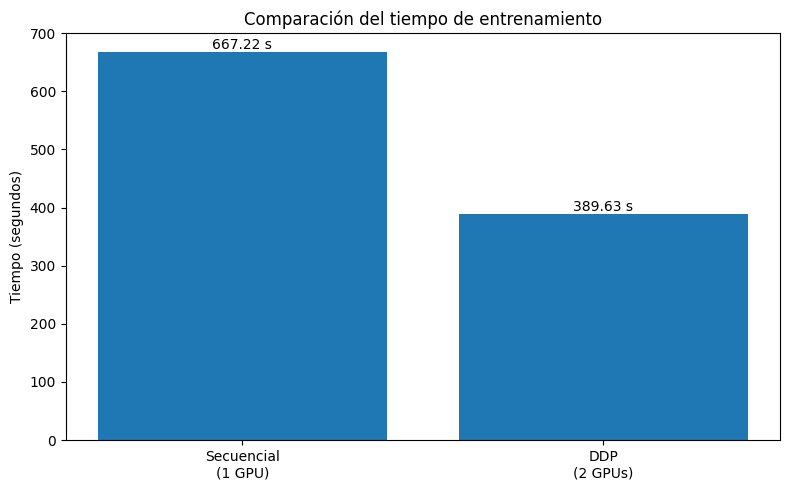

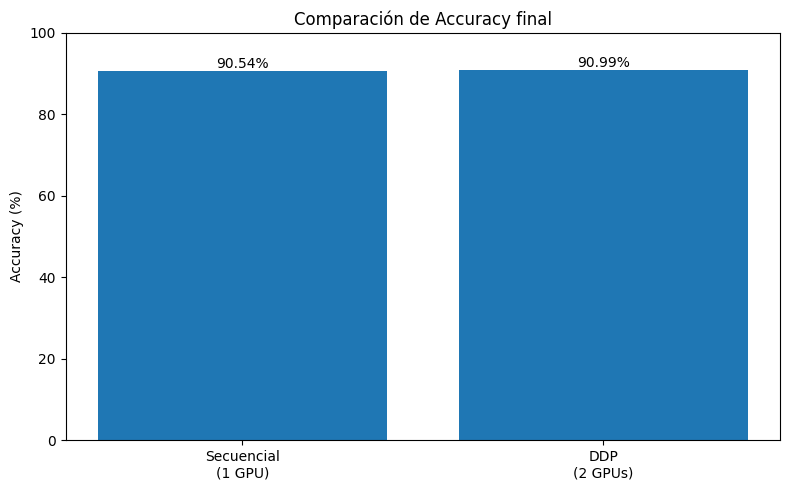

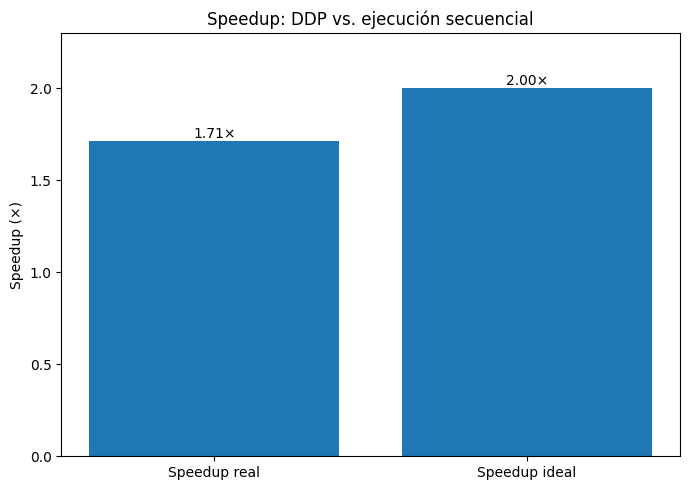

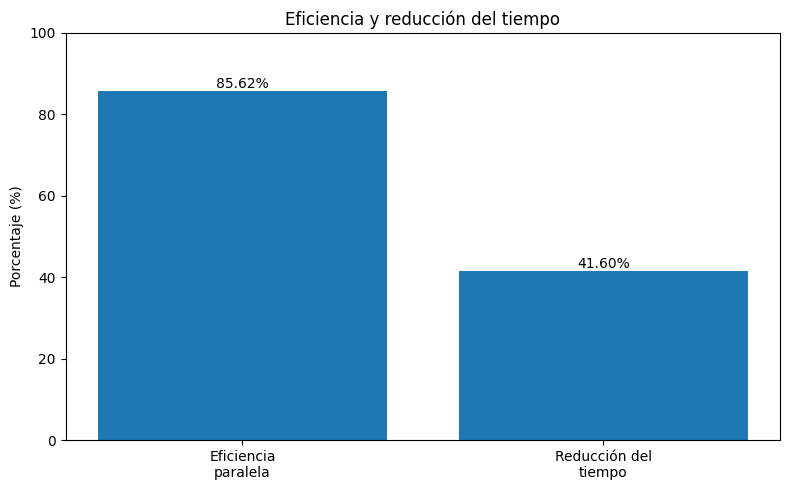

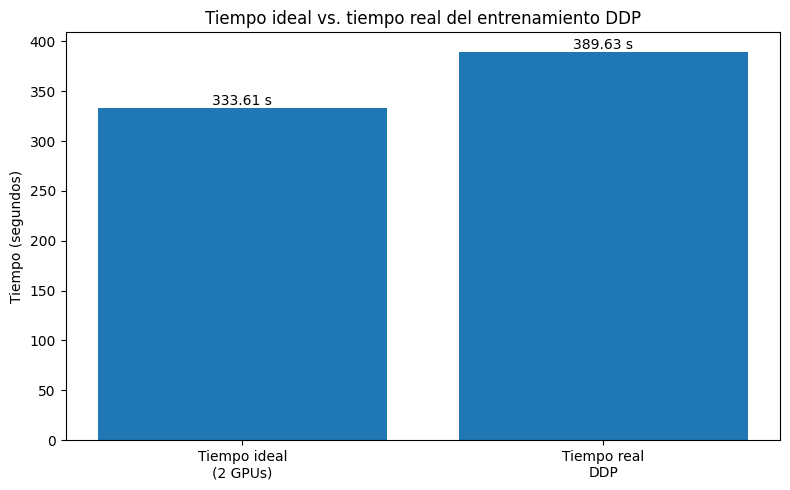


MÉTRICAS PARA EL INFORME
T1 (secuencial):       667.22 s
T2 (DDP):              389.63 s
Speedup:               1.71x
Eficiencia:            85.62%
Reducción:             41.60%
Tiempo ideal (2 GPU):  333.61 s
Overhead:              56.02 s
Baseline accuracy:     90.54%
DDP accuracy:          90.99%


In [18]:
# ============================================================
# GRÁFICAS COMPARATIVAS FINALES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# DATOS FINALES
# ------------------------------------------------------------

T1 = 667.22
T2 = 389.63

baseline_acc = 90.54
ddp_acc = 90.99

speedup = T1 / T2
efficiency = speedup / 2 * 100
reduction = (T1 - T2) / T1 * 100
ideal_time = T1 / 2
overhead = T2 - ideal_time

# ------------------------------------------------------------
# 1. COMPARACIÓN DE TIEMPO DE EJECUCIÓN
# ------------------------------------------------------------

labels = ["Secuencial\n(1 GPU)", "DDP\n(2 GPUs)"]
times = [T1, T2]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, times)

plt.ylabel("Tiempo (segundos)")
plt.title("Comparación del tiempo de entrenamiento")

for bar, value in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "comparacion_tiempo.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 2. COMPARACIÓN DE ACCURACY
# ------------------------------------------------------------

labels = ["Secuencial\n(1 GPU)", "DDP\n(2 GPUs)"]
accuracy = [baseline_acc, ddp_acc]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Comparación de Accuracy final")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "comparacion_accuracy.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 3. SPEEDUP
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

labels = ["Speedup real", "Speedup ideal"]
values = [speedup, 2.0]

bars = plt.bar(labels, values)

plt.ylabel("Speedup (×)")
plt.title("Speedup: DDP vs. ejecución secuencial")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}×",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 2.3)

plt.tight_layout()
plt.savefig(
    "speedup_comparacion.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 4. EFICIENCIA Y REDUCCIÓN DEL TIEMPO
# ------------------------------------------------------------

labels = [
    "Eficiencia\nparalela",
    "Reducción del\ntiempo"
]

values = [
    efficiency,
    reduction
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Porcentaje (%)")
plt.title("Eficiencia y reducción del tiempo")
plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "eficiencia_reduccion.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 5. TIEMPO REAL VS TIEMPO IDEAL
# ------------------------------------------------------------

labels = [
    "Tiempo ideal\n(2 GPUs)",
    "Tiempo real\nDDP"
]

values = [
    ideal_time,
    T2
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo ideal vs. tiempo real del entrenamiento DDP")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "tiempo_ideal_vs_real.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# RESUMEN
# ------------------------------------------------------------

print("\n========================================")
print("MÉTRICAS PARA EL INFORME")
print("========================================")
print(f"T1 (secuencial):       {T1:.2f} s")
print(f"T2 (DDP):              {T2:.2f} s")
print(f"Speedup:               {speedup:.2f}x")
print(f"Eficiencia:            {efficiency:.2f}%")
print(f"Reducción:             {reduction:.2f}%")
print(f"Tiempo ideal (2 GPU):  {ideal_time:.2f} s")
print(f"Overhead:              {overhead:.2f} s")
print(f"Baseline accuracy:     {baseline_acc:.2f}%")
print(f"DDP accuracy:          {ddp_acc:.2f}%")
print("========================================")